سوال 4 بخش الف

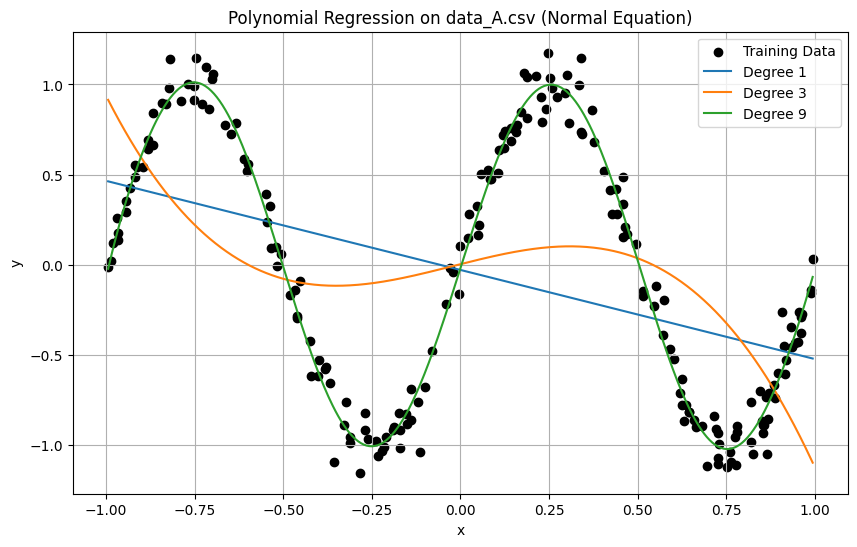

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# بارگذاری داده‌ها
data_a = pd.read_csv('data_A.csv')
x = data_a['x'].values
y = data_a['y'].values

def get_design_matrix(x, degree):
    """ساخت ماتریس طراحی بر اساس درجه چندجمله‌ای"""
    X_design = np.column_stack([x**i for i in range(degree + 1)])
    return X_design

def solve_normal_equation(X, y):
    """محاسبه وزن‌ها با استفاده از معادله نرمال"""
    return np.linalg.inv(X.T @ X) @ X.T @ y

# درجات مورد نظر در صورت سوال
degrees = [1, 3, 9]

# رسم نمودار داده‌های اصلی
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Training Data')

# ایجاد نقاط برای رسم منحنی نرم (Dense Grid)
x_grid = np.linspace(min(x), max(x), 500)

for d in degrees:
    # مرحله آموزش: محاسبه وزن‌ها
    X_train = get_design_matrix(x, d)
    theta = solve_normal_equation(X_train, y)
    
    # مرحله پیش‌بینی: محاسبه خروجی برای گرید ساخته شده
    X_grid = get_design_matrix(x_grid, d)
    y_pred = X_grid @ theta
    
    # اضافه کردن منحنی به نمودار
    plt.plot(x_grid, y_pred, label=f'Degree {d}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression on data_A.csv (Normal Equation)')
plt.legend()
plt.grid(True)
plt.show()

سوال 4 بخش ب

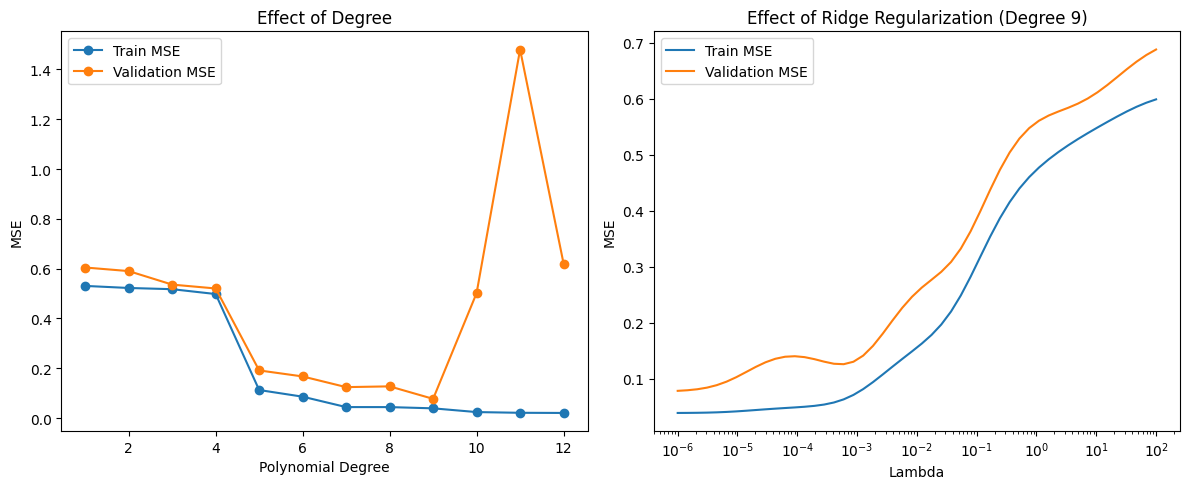

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# بارگذاری و آماده‌سازی داده‌ها
# از آنجایی که فرمودید دیتاست‌های جدا شده را دارید، مستقیماً بارگذاری می‌کنیم
train_data = pd.read_csv('data_B_train.csv')
val_data = pd.read_csv('data_B_val.csv')

x_train, y_train = train_data['x'].values, train_data['y'].values
x_val, y_val = val_data['x'].values, val_data['y'].values

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# --- بخش 1: اثر درجه چندجمله‌ای ---
degrees = np.arange(1, 13)
train_mses = []
val_mses = []

for d in degrees:
    X_train = np.column_stack([x_train**i for i in range(d + 1)])
    X_val = np.column_stack([x_val**i for i in range(d + 1)])
    
    theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
    
    train_mses.append(mse(y_train, X_train @ theta))
    val_mses.append(mse(y_val, X_val @ theta))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(degrees, train_mses, label='Train MSE', marker='o')
plt.plot(degrees, val_mses, label='Validation MSE', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Effect of Degree')
plt.legend()

# --- بخش 2: اثر رگولاریزاسیون Ridge ---
d_fixed = 9
lambdas = np.logspace(-6, 2, 50)
ridge_train_mses = []
ridge_val_mses = []

X_train_9 = np.column_stack([x_train**i for i in range(d_fixed + 1)])
X_val_9 = np.column_stack([x_val**i for i in range(d_fixed + 1)])
I = np.eye(d_fixed + 1)

for l in lambdas:
    # فرمول ریج: (X'X + lambda*I)^-1 * X'y
    theta_ridge = np.linalg.inv(X_train_9.T @ X_train_9 + l * I) @ X_train_9.T @ y_train
    
    ridge_train_mses.append(mse(y_train, X_train_9 @ theta_ridge))
    ridge_val_mses.append(mse(y_val, X_val_9 @ theta_ridge))

plt.subplot(1, 2, 2)
plt.semilogx(lambdas, ridge_train_mses, label='Train MSE')
plt.semilogx(lambdas, ridge_val_mses, label='Validation MSE')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.title('Effect of Ridge Regularization (Degree 9)')
plt.legend()
plt.tight_layout()
plt.show()